In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

In [2]:
figures_dir = '../figures'  
os.makedirs(figures_dir, exist_ok=True)

In [3]:
df = pd.read_csv(r'../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.drop(labels='customerID', axis=1, inplace=True)
df.iloc[:5, :10]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes
1,Male,0,No,No,34,Yes,No,DSL,Yes,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No


In [4]:
df.iloc[:5, 10:]

,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.select_dtypes(include=['int', 'float']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SeniorCitizen   7043 non-null   int64  
 1   tenure          7043 non-null   int64  
 2   MonthlyCharges  7043 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 165.2 KB


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(
    value=df['TotalCharges'].median()
)

In [8]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

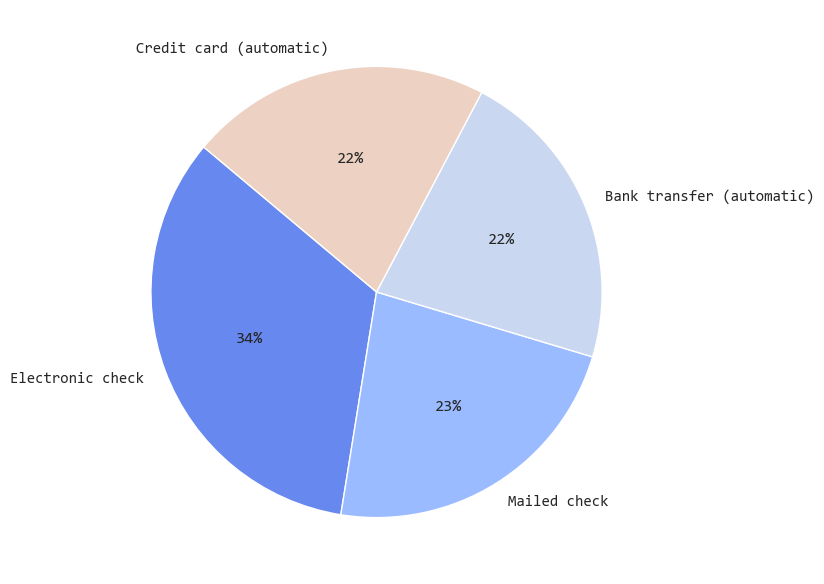

In [9]:
sns.set_theme(style='whitegrid', palette='coolwarm', font='consolas')
plt.figure(figsize=(8,6))
df['PaymentMethod'].value_counts().plot.pie(
    startangle=140,
    autopct='%1.f%%'
)
plt.ylabel('')
plt.tight_layout()
output_path = os.path.join(figures_dir, 'payment_method_distribution.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

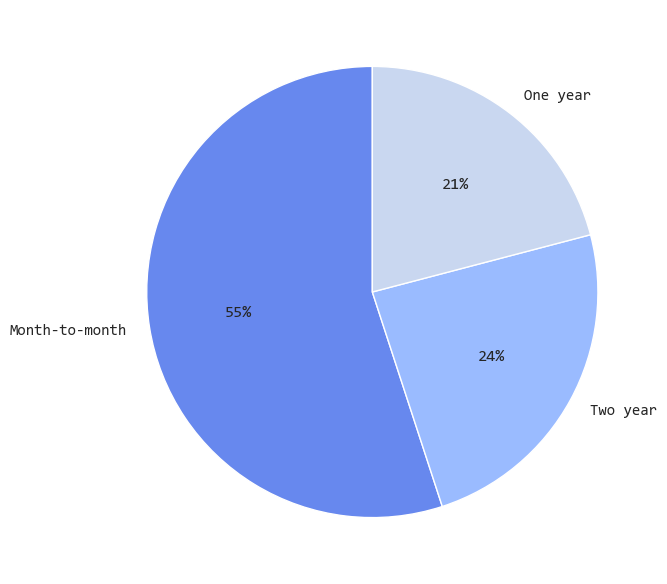

In [10]:
plt.figure(figsize=(8,6))
df['Contract'].value_counts().plot.pie(
    startangle=90,
    autopct='%1.f%%'
)
plt.ylabel('')
plt.tight_layout()
output_path = os.path.join(figures_dir, 'contract_distribution.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

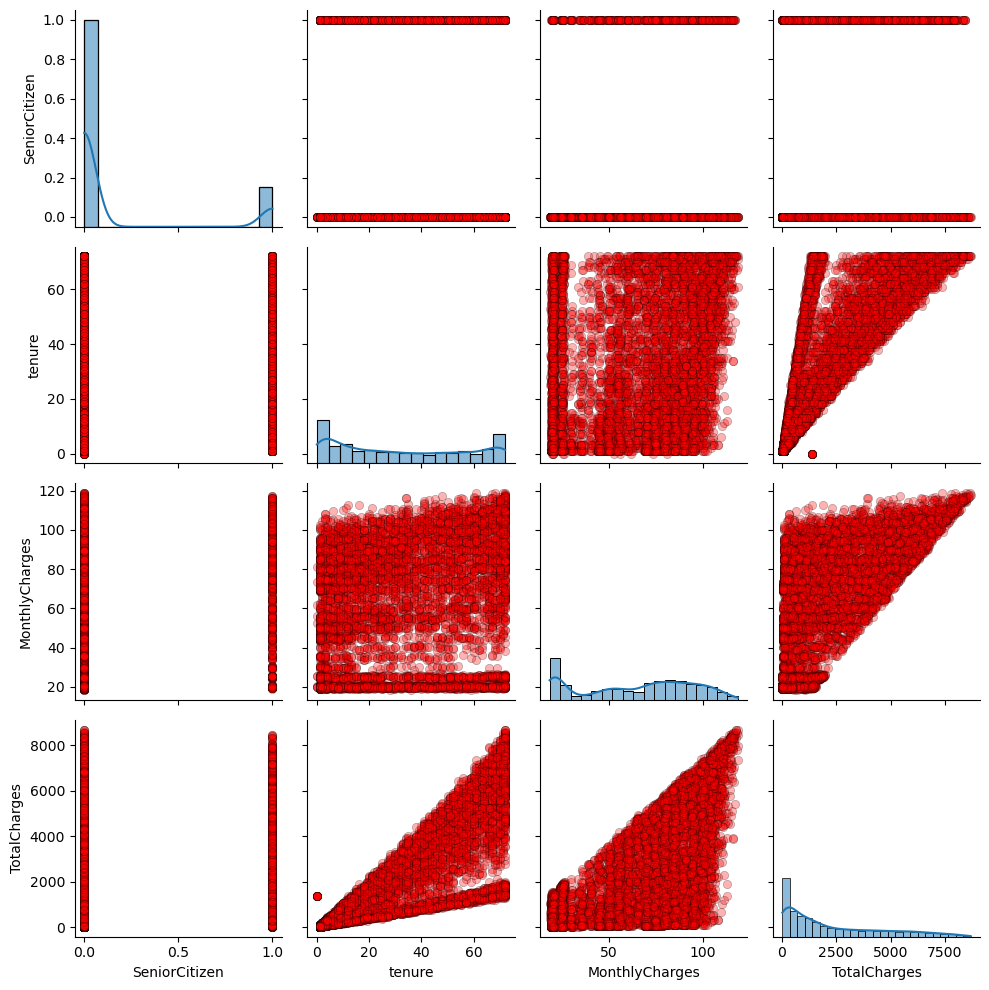

In [11]:
sns.reset_defaults()
numeric_columns = df.select_dtypes(include=['int', 'float']).columns
sns.pairplot(
    data=df[numeric_columns],
    plot_kws={
        'color': 'red',
        'edgecolor': 'k',
        'alpha': 0.3
    },
    diag_kws={
        'kde': True
    }
)
plt.tight_layout()
output_path = os.path.join(figures_dir, 'pairplot.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

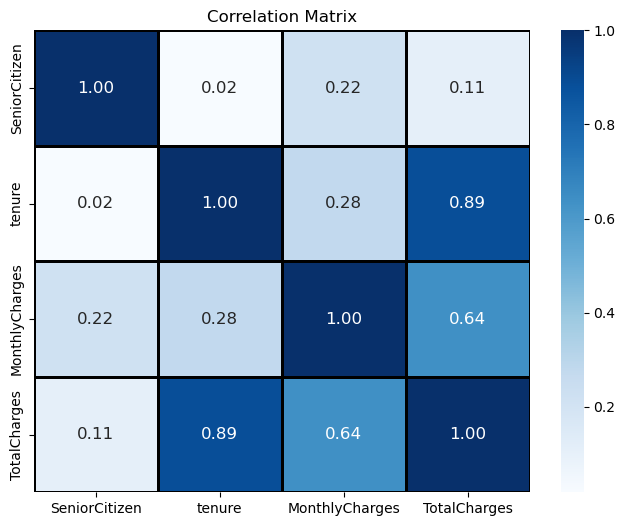

In [12]:
corr = df.corr(numeric_only=True, method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(
    corr, 
    cmap='Blues',
    annot=True,
    annot_kws={
        'size':12
    },
    linecolor='k',
    linewidths=1,
    fmt='.2f'
)
plt.title('Correlation Matrix')
output_path = os.path.join(figures_dir, 'correlation_matrix.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
# plt.tight_layout()
plt.show()

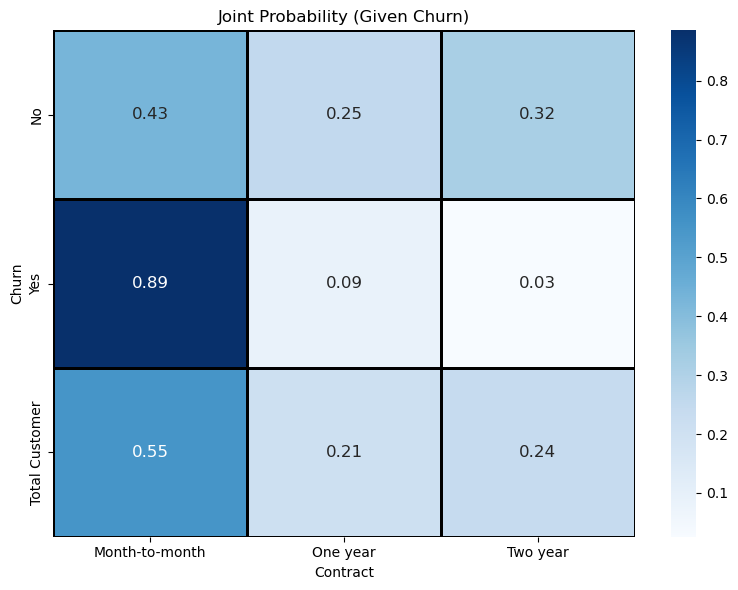

In [13]:
cross = pd.crosstab(
    index=df['Churn'],
    columns=df['Contract'],
    margins=True,
    margins_name='Total Customer',
    normalize='index',
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cross, 
    cmap='Blues',
    annot=True,
    annot_kws={
        'size':12
    },
    linecolor='k',
    linewidths=1,
    fmt='.2f'
)
plt.title('Joint Probability (Given Churn)')
output_path = os.path.join(figures_dir, 'joint_probability.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [14]:
df['churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

df['contract'] = df['Contract'].map({
    'Month-to-month': 0, 
    'One year': 1,
    'Two year': 2
})
numeric_columns = numeric_columns.to_list()
numeric_columns.extend(['churn', 'contract'])




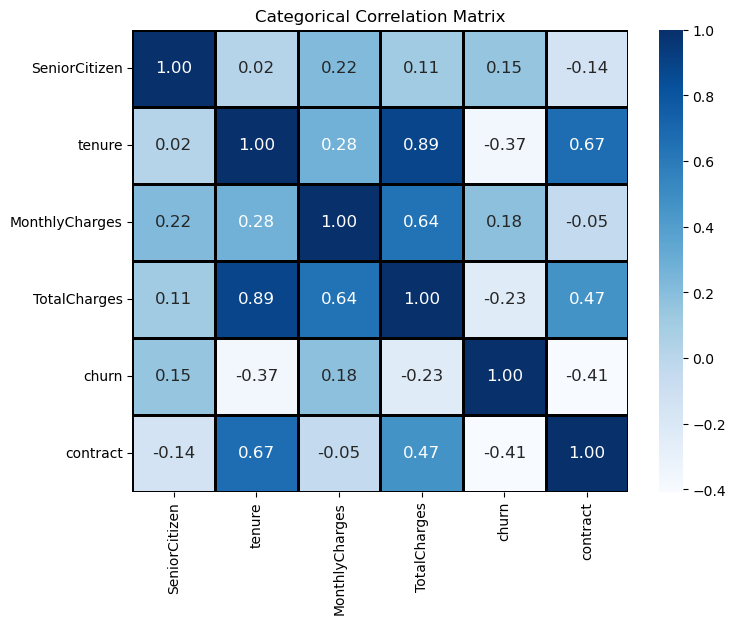

In [15]:
corr = df[numeric_columns].corr( method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(
    corr, 
    cmap='Blues',
    annot=True,
    annot_kws={
        'size':12
    },
    linecolor='k',
    linewidths=1,
    fmt='.2f'
)
plt.title('Categorical Correlation Matrix')
output_path = os.path.join(figures_dir, 'cat_correlation_matrix.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
# plt.tight_layout()
plt.show()

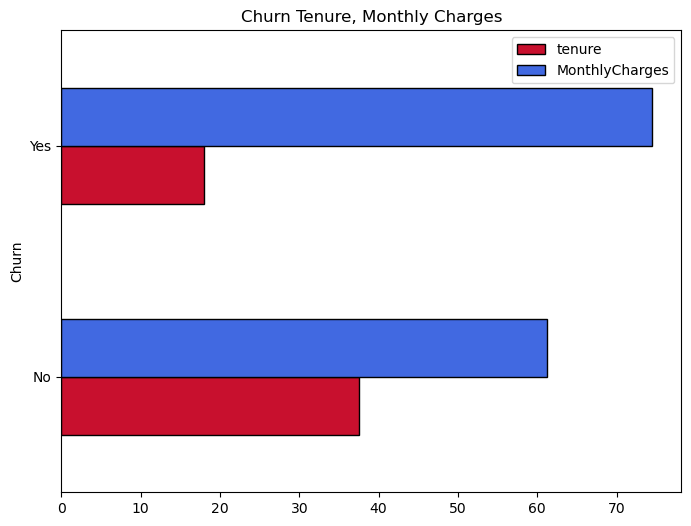

In [16]:
df.groupby(by='Churn')[['tenure', 'MonthlyCharges']].mean().plot(
    kind='barh',
    figsize=(8,6),
    color=['#C8102E', 'royalblue'],
    edgecolor='k'
)
plt.title('Churn Tenure, Monthly Charges')
output_path = os.path.join(figures_dir, 'bar_plot.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

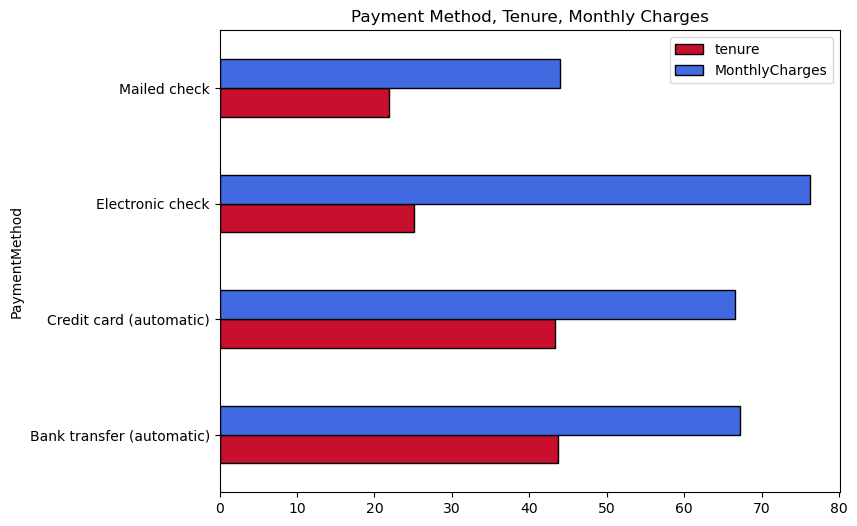

In [17]:
df.groupby(by='PaymentMethod')[['tenure', 'MonthlyCharges']].mean().plot(
    kind='barh',
    figsize=(8,6),
    color=['#C8102E', 'royalblue'],
    edgecolor='k'
)
plt.title('Payment Method, Tenure, Monthly Charges')
output_path = os.path.join(figures_dir, 'bar_plot_2.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

In [18]:
cat_cols = df.select_dtypes(include=['object']).columns

df[cat_cols].describe()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


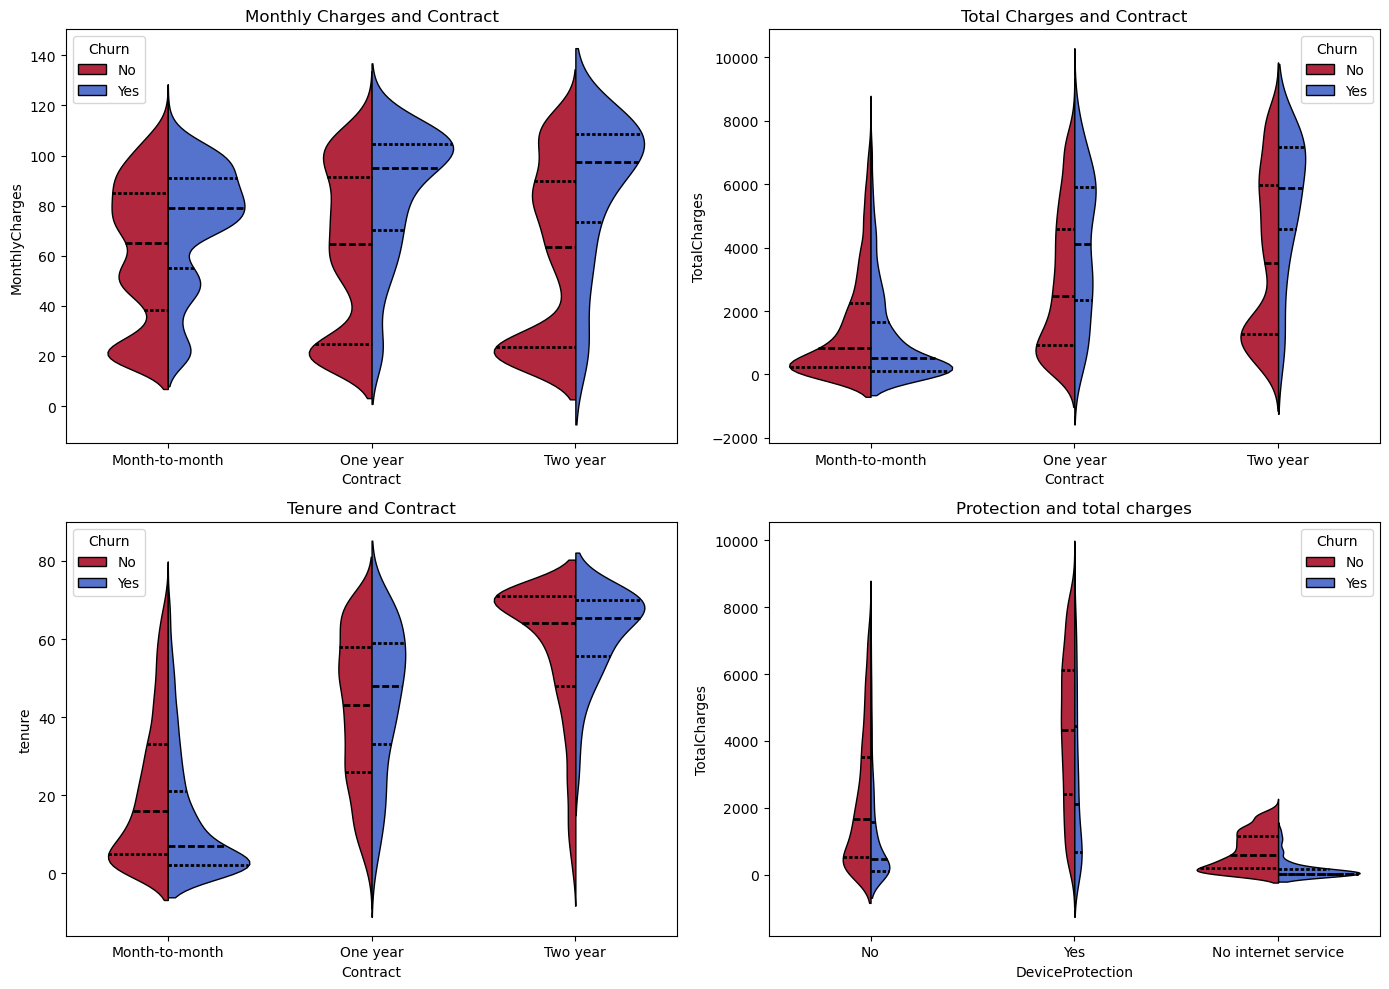

In [74]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))
ax = ax.flatten()
sns.violinplot(
    data=df, 
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    linewidth=1,
    linecolor='k',
    split=True,
    inner='quart',
    inner_kws={
        'linewidth': 2
    },
    palette=['#C8102E', 'royalblue'],
    ax=ax[0]
)
ax[0].set_title('Monthly Charges and Contract')


sns.violinplot(
    data=df, 
    x='Contract',
    y='TotalCharges',
    hue='Churn',
    linewidth=1,
    linecolor='k',
    split=True,
    inner='quart',
    inner_kws={
        'linewidth': 2
    },
    palette=['#C8102E', 'royalblue'],
    ax=ax[1]
)
ax[1].set_title('Total Charges and Contract')

sns.violinplot(
    data=df, 
    x='Contract',
    y='tenure',
    hue='Churn',
    linewidth=1,
    linecolor='k',
    split=True,
    inner='quart',
    inner_kws={
        'linewidth': 2
    },
    palette=['#C8102E', 'royalblue'],
    ax=ax[2]
)
ax[2].set_title('Tenure and Contract')

sns.violinplot(
    data=df, 
    x='DeviceProtection',
    y='TotalCharges',
    hue='Churn',
    linewidth=1,
    linecolor='k',
    split=True,
    inner='quart',
    inner_kws={
        'linewidth': 2
    },
    palette=['#C8102E', 'royalblue'],
    ax=ax[3]
)
ax[3].set_title('Protection and total charges')
plt.tight_layout()


output_path = os.path.join(figures_dir, 'grouped_violin_plot.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

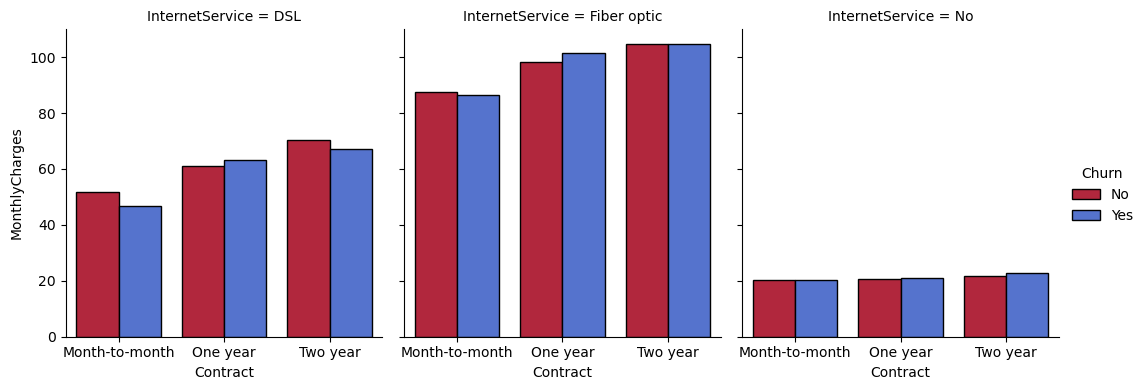

In [161]:
sns.catplot(
    data=df, 
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    col='InternetService',
    kind='bar',
    errorbar=None,
    estimator='mean',
    edgecolor='k',
    col_wrap=3,
    palette=['#C8102E', 'royalblue'],
    height=4,
    aspect=0.9
)

output_path = os.path.join(figures_dir, 'categorical_grouped_barplot.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()